tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.62G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.62G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/115 [00:00<?, ?B/s]

Inference Time - MHA (GPT2-Medium): 0.815 seconds
Inference Time - MQA (Falcon-RW-1B): 5.698 seconds


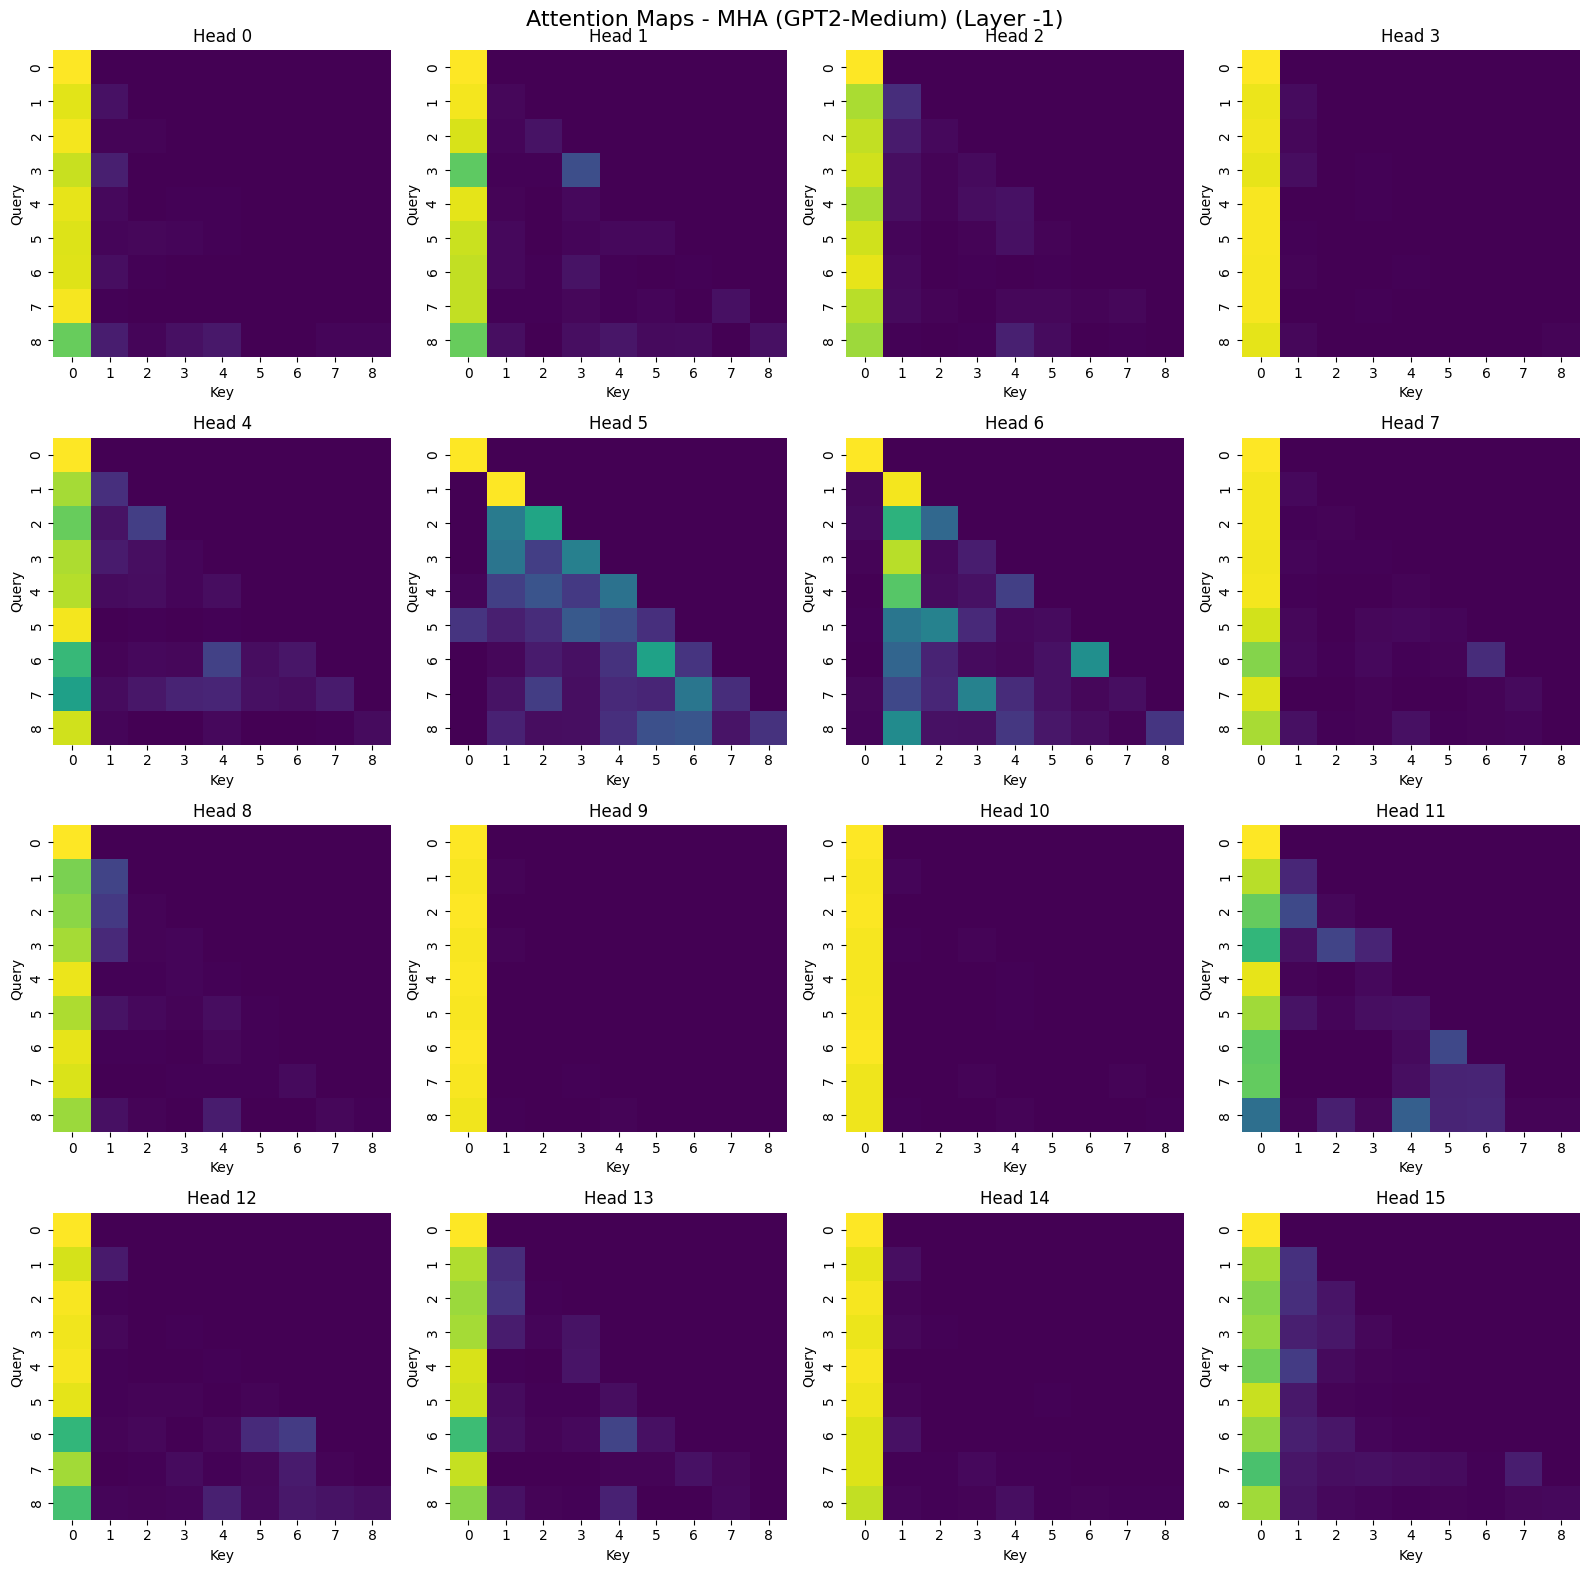

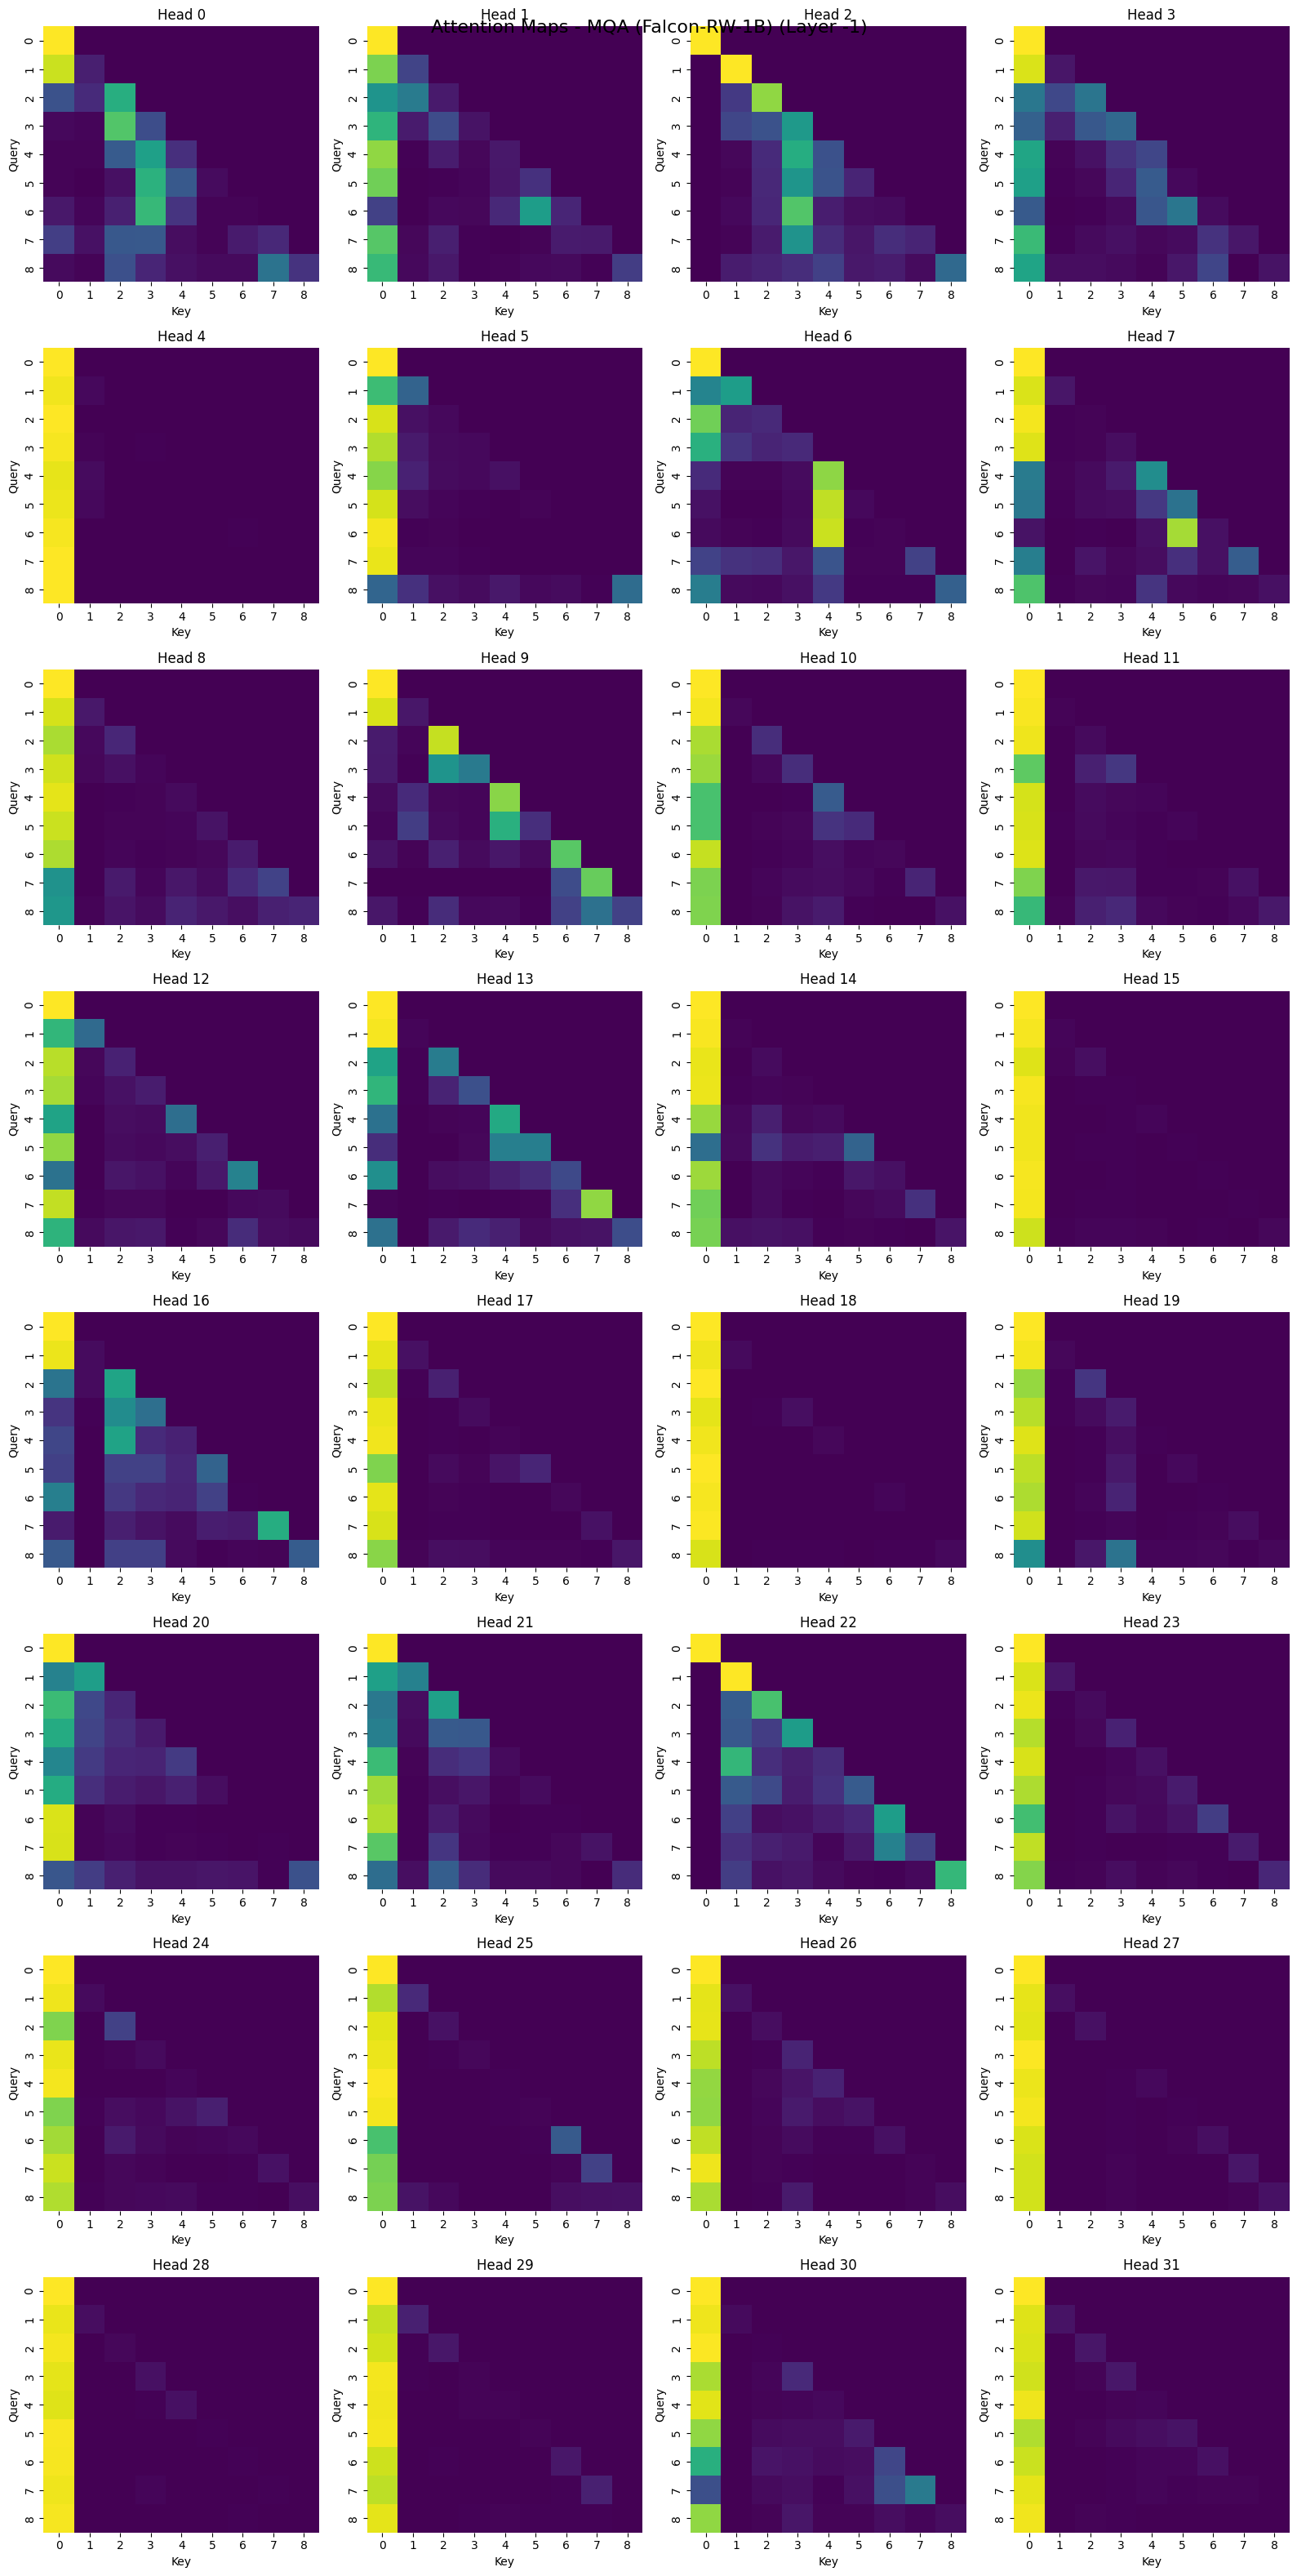

In [ ]:
import torch
import time
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForCausalLM

# Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"

# Define your models
MHA_MODEL = "gpt2-medium"
MQA_MODEL = "tiiuae/falcon-rw-1b"

# Load tokenizers
tokenizer_mha = AutoTokenizer.from_pretrained(MHA_MODEL)
tokenizer_mqa = AutoTokenizer.from_pretrained(MQA_MODEL)

# Prompt to test
prompt = "The quick brown fox jumps over the lazy dog"

def get_attention_outputs(model_name, tokenizer, prompt):
    print(f"Loading model: {model_name}")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        low_cpu_mem_usage=True,
        output_attentions=True
    ).to(device)
    model.eval()

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        start_time = time.time()
        outputs = model(**inputs)
        end_time = time.time()

    latency = end_time - start_time
    return outputs.attentions, model, inputs, latency

# Step 2: Compare inference times of MHA and MQA

# Run MHA model (GPT2-medium)
attn_mha, model_mha, _, time_mha = get_attention_outputs(MHA_MODEL, tokenizer_mha, prompt)
torch.cuda.empty_cache()

# Run MQA model (Falcon-RW-1B)
attn_mqa, model_mqa, _, time_mqa = get_attention_outputs(MQA_MODEL, tokenizer_mqa, prompt)
torch.cuda.empty_cache()

# Print inference time
print(f"Inference Time - MHA (GPT2-Medium): {time_mha:.3f} seconds")
print(f"Inference Time - MQA (Falcon-RW-1B): {time_mqa:.3f} seconds")

def plot_all_heads(attn_scores, label, layer=-1):
    attn = attn_scores[layer][0].detach().cpu() # [num_heads, seq_len, seq_len]
    num_heads = attn.shape[0]
    seq_len = attn.shape[1]

    cols = 4
    rows = (num_heads + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    fig.suptitle(f"Attention Maps - {label} (Layer {layer})", fontsize=16)

    for i in range(rows * cols):
        r, c = divmod(i, cols)
        ax = axes[r, c] if rows > 1 else axes[c]
        if i < num_heads:
            sns.heatmap(attn[i], ax=ax, cmap="viridis", cbar=False)
            ax.set_title(f"Head {i}")
            ax.set_xlabel("Key")
            ax.set_ylabel("Query")
        else:
            ax.axis("off") # Hide unused subplots

    plt.tight_layout()
    plt.show()

# Plot attention heads
plot_all_heads(attn_mha, "MHA (GPT2-Medium)", layer=-1)
plot_all_heads(attn_mqa, "MQA (Falcon-RW-1B)", layer=-1)

[GPT2-Medium] Key shape: torch.Size([1024, 1024]), Value shape: torch.Size([1024, 1024])
[Falcon-RW-1B] Key shape: torch.Size([2048, 2048]), Value shape: torch.Size([2048, 2048])

GPT2-Medium (MHA) - Key Projections


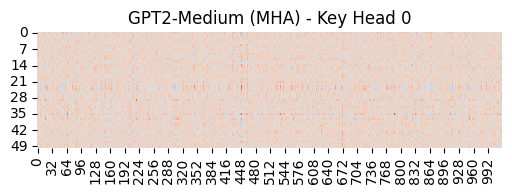

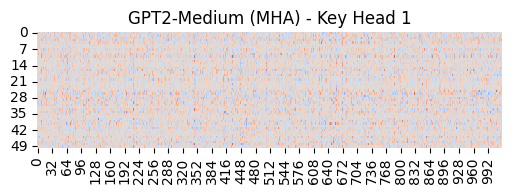

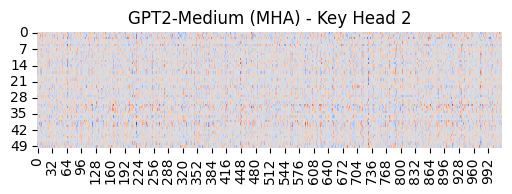

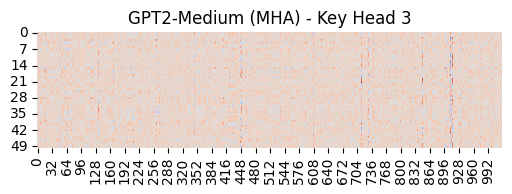

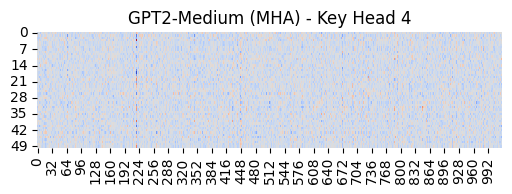

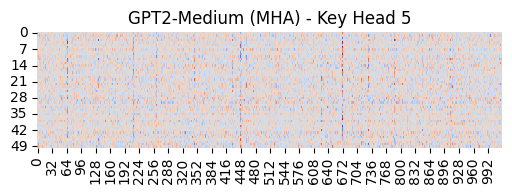


GPT2-Medium (MHA) - Value Projections


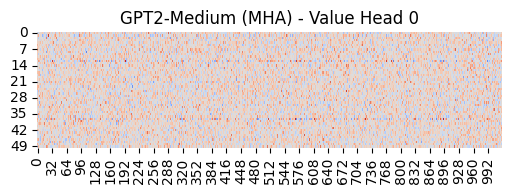

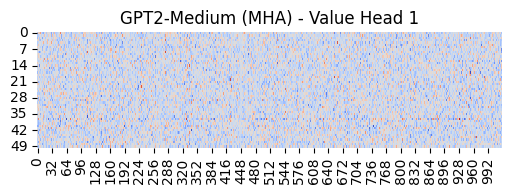

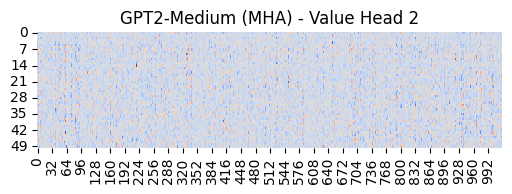

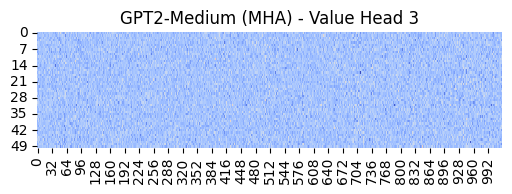

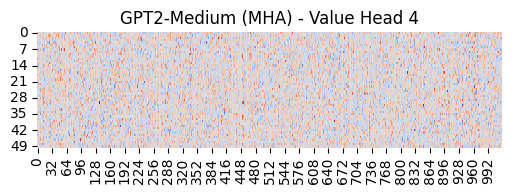

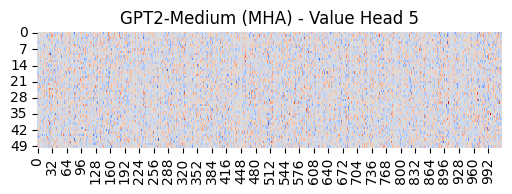


Falcon-RW-1B (MQA) - Key Projections


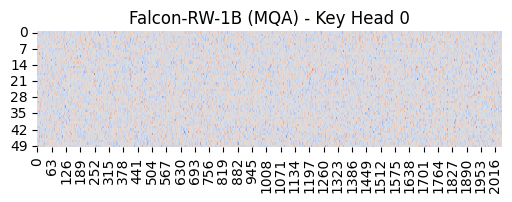

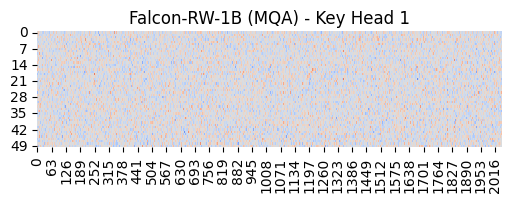

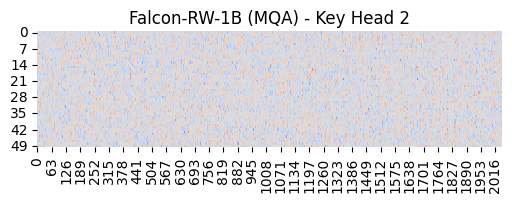

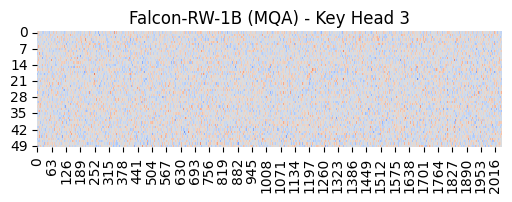

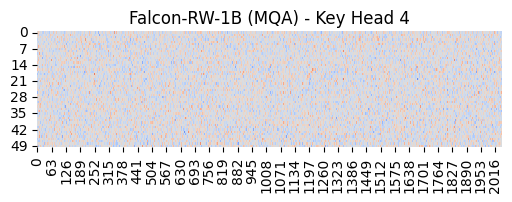

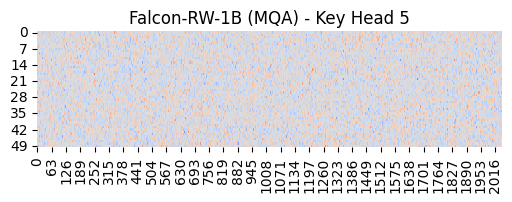


Falcon-RW-1B (MQA) - Value Projections


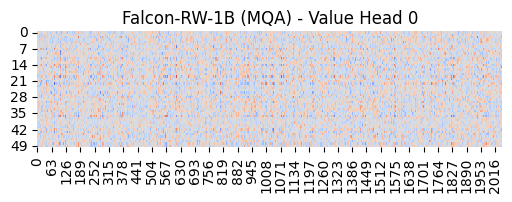

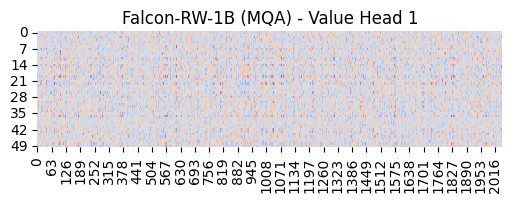

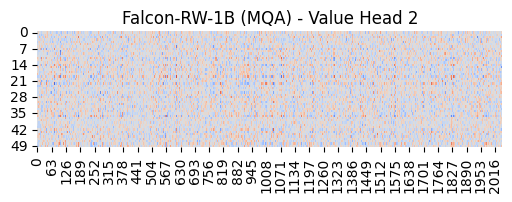

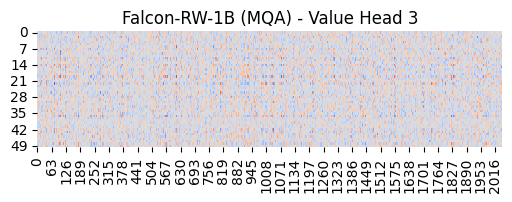

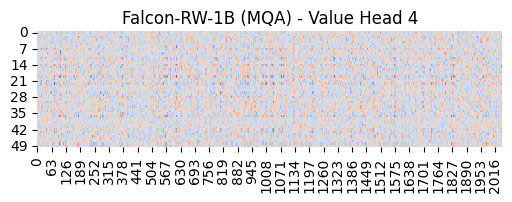

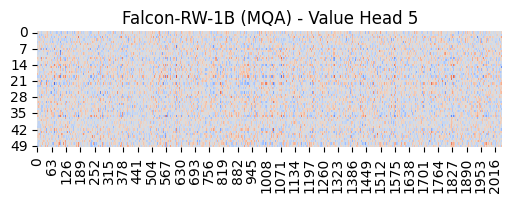

In [ ]:
# Step 4: Compare key-value matrices for all heads

def extract_falcon_kv_weights(model, layer_idx=0):
    layer = model.transformer.h[layer_idx]
    qkv_proj = layer.self_attention.query_key_value.weight.detach().cpu() # [3 * hidden, hidden]
    W_q, W_k, W_v = torch.chunk(qkv_proj, 3, dim=0)
    return W_k, W_v

def extract_gpt2_kv_weights(model, layer_idx=0):
    layer = model.transformer.h[layer_idx]
    W_qkv = layer.attn.c_attn.weight.detach().cpu() # shape: [1024, 3072]
    W_q, W_k, W_v = torch.chunk(W_qkv, 3, dim=1) # split across input dims
    return W_k.T, W_v.T # transpose to get [output_dim, input_dim]

try:
    W_k_mha, W_v_mha = extract_gpt2_kv_weights(model_mha)
    print(f"[GPT2-Medium] Key shape: {W_k_mha.shape}, Value shape: {W_v_mha.shape}")
except Exception as e:
    print(f"[GPT2-Medium] Failed to extract KV: {e}")

try:
    W_k_mqa, W_v_mqa = extract_falcon_kv_weights(model_mqa)
    print(f"[Falcon-RW-1B] Key shape: {W_k_mqa.shape}, Value shape: {W_v_mqa.shape}")
except Exception as e:
    print(f"[Falcon-RW-1B] Failed to extract KV: {e}")

def visualize_kv_heads(W_k, W_v, num_heads, model_label):
    head_dim = W_k.shape[1] // num_heads

    print(f"\n{model_label} - Key Projections")
    for i in range(min(6, num_heads)):
        head_k = W_k[i * head_dim:(i + 1) * head_dim, :]
        plt.figure(figsize=(6, 1.5))
        sns.heatmap(head_k[:50], cmap="coolwarm", cbar=False)
        plt.title(f"{model_label} - Key Head {i}")
        plt.show()

    print(f"\n{model_label} - Value Projections")
    for i in range(min(6, num_heads)):
        head_v = W_v[i * head_dim:(i + 1) * head_dim, :]
        plt.figure(figsize=(6, 1.5))
        sns.heatmap(head_v[:50], cmap="coolwarm", cbar=False)
        plt.title(f"{model_label} - Value Head {i}")
        plt.show()

# GPT2-Medium
visualize_kv_heads(W_k_mha, W_v_mha, num_heads=model_mha.config.n_head, model_label="GPT2-Medium (MHA)")

# Falcon-RW-1B
# For MQA, all heads share the same projection, so we just tile it
num_heads_mqa = model_mqa.config.num_attention_heads

# Calculate head_dim for Falcon to create the representative slice
head_dim_falcon = model_mqa.config.hidden_size // num_heads_mqa

# Repeat a representative slice (first head_dim_falcon rows) of the single K/V projection
W_k_mqa_repeated = W_k_mqa[:head_dim_falcon, :].repeat(num_heads_mqa, 1)
W_v_mqa_repeated = W_v_mqa[:head_dim_falcon, :].repeat(num_heads_mqa, 1)

visualize_kv_heads(W_k_mqa_repeated, W_v_mqa_repeated, num_heads=num_heads_mqa, model_label="Falcon-RW-1B (MQA)")